# descriptive data exploration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("data_for_student.parquet")
meta = pd.read_parquet("metadata_for_student.parquet")
print("data:", df.shape)
print("metadata:", meta.shape)

data: (355532, 5)
metadata: (350113, 3)


## data overview

In [15]:
# schema and first rows
print(df.dtypes)
print('-----')
df.head()

raw_file            object
scan_number          int64
peptide_sequence    object
intensities_raw     object
matched_ions        object
dtype: object
-----


,raw_file,scan_number,peptide_sequence,intensities_raw,matched_ions
0,01650b_BG4-TUM_first_pool_73_01_01-2xIT_2xHCD-...,48156,HLTVEELFGTSLPK,"[116.713806152344, 54029.1484375, 1521.8664550...","[y1, y2, b2, b3, y3, y4, b4, y5, b5, y6, b6, y..."
1,02208a_GC10-TUM_second_addon_34_01_01-2xIT_2xH...,5465,SM[UNIMOD:35]ASNHETAHNVIC[UNIMOD:4]K,"[10120.6884765625, 133350.921875, 22052.142578...","[y1, b2, b3, y2, b4, y3, b5, y4, y5, b6, y6, y..."
2,02080d_GB1-TUM_isoform_109_01_01-2xIT_2xHCD-1h-R1,29548,PHKC[UNIMOD:4]PDC[UNIMOD:4]DMAFVTSGELVR,"[11643.265625, 12050.8876953125, 48106.8476562...","[y1, b2, y2, b3, y3, y4, b4, y5, b5, y6, b6, y..."
3,02097a_BF10-TUM_isoform_70_01_01-2xIT_2xHCD-1h-R3,53980,KQPALDVLYDVMK,"[1181.60241699219, 475.930603027344, 450.20574...","[b2, y2, b3, y3, b4, y4, b5, b6, y5, b7, y6, b..."
4,02080d_GA9-TUM_isoform_105_01_01-DDA-1h-R1,26218,HPGHIHKLLAQQLVSPVK,"[8962.16015625, 68957.0, 6599.31884765625, 827...","[y1, b2, y2, b3, y3, b4, y4, y5, b5, y6, b6, y..."


In [16]:
# missing values and unique counts
print("missing values")
print(df.isnull().sum())
print()
print("unique counts")
for c in ["raw_file", "scan_number", "peptide_sequence"]:
    print(f"  {c}: {df[c].nunique()}")

missing values
raw_file            0
scan_number         0
peptide_sequence    0
intensities_raw     0
matched_ions        0
dtype: int64

unique counts
  raw_file: 1113
  scan_number: 63259
  peptide_sequence: 355532


In [17]:
# scan_number distribution
df["scan_number"].describe()

count    355532.000000
mean      29724.875511
std       14951.747507
min        1009.000000
25%       17868.000000
50%       29083.000000
75%       40495.000000
max       82893.000000
Name: scan_number, dtype: float64

## metadata overview

In [18]:
# schema and first rows
print(meta.dtypes)
print()
meta.head()

raw_file            object
scan_number          int64
precursor_charge     int64
dtype: object



,raw_file,scan_number,precursor_charge
73,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2,22450,2
169,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2,14545,2
303,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2,25465,2
306,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2,11518,2
358,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2,30691,2


In [19]:
# precursor charge distribution
meta["precursor_charge"].value_counts().sort_index()

precursor_charge
1        57
2    213729
3    125161
4     10943
5       217
6         6
Name: count, dtype: int64

## joint analysis

In [20]:
# raw_file overlap between data and metadata
data_files = set(df["raw_file"].unique())
meta_files = set(meta["raw_file"].unique())
print(f"raw_files in data only: {len(data_files - meta_files)}")
print(f"raw_files in meta only: {len(meta_files - data_files)}")
print(f"raw_files in both: {len(data_files & meta_files)}")

# inner join on shared keys
    merged = df.merge(meta, on=["raw_file", "scan_number"], how="inner")
print(f"\ninner join: {merged.shape[0]} rows ({merged.shape[0]/len(df)*100:.1f}% of data)")
print(f"left-only rows: {len(df) - merged.shape[0]}")

# merged.head().iloc[0]['matched_ions']
um = df.merge(meta, on=["raw_file", "scan_number"], how="outer")

um [um["precursor_charge"].isnull()]

merged.iloc[2].iloc[3]

IndentationError: unexpected indent (3595668145.py, line 9)

## peptide sequences

In [ ]:
# sequence length distribution
seq_lens = df["peptide_sequence"].str.len()
print(seq_lens.describe())
print()

# fraction of peptides with modifications
has_mod = df["peptide_sequence"].str.contains(r"\[UNIMOD:", regex=True)
print(f"modified peptides: {has_mod.sum()} ({has_mod.mean()*100:.1f}%)")
print(f"unmodified peptides: {(~has_mod).sum()} ({(~has_mod).mean()*100:.1f}%)")

count    355532.000000
mean         18.477783
std           9.602331
min           7.000000
25%          11.000000
50%          16.000000
75%          24.000000
max         107.000000
Name: peptide_sequence, dtype: float64

modified peptides: 126689 (35.6%)
unmodified peptides: 228843 (64.4%)


## intensities and matched ions

In [ ]:
# array lengths per row (intensities and ions are always the same length)
arr_lens = df["intensities_raw"].apply(len)
print("fragment count per spectrum")
print(arr_lens.describe())
print()

# most common ion types
all_ions = np.concatenate(df["matched_ions"].values)
ion_counts = pd.Series(all_ions).value_counts().head(15)
print("top 15 ion types")
print(ion_counts)

fragment count per spectrum
count    355532.000000
mean         19.839621
std           5.252385
min           7.000000
25%          16.000000
50%          19.000000
75%          23.000000
max          48.000000
Name: intensities_raw, dtype: float64

top 15 ion types
y5    352296
y4    351982
y6    351889
y3    351532
b6    350632
b5    349925
b4    349623
b3    342410
y7    341980
b7    336256
y2    323954
y8    309757
b8    307016
b9    268349
b2    267757
Name: count, dtype: int64


In [ ]:
# intensity value distribution across all spectra
all_intensities = np.concatenate(df["intensities_raw"].values)
print("intensity values across all spectra")
print(pd.Series(all_intensities).describe())

intensity values across all spectra
count    7.053620e+06
mean     1.190278e+05
std      5.855697e+05
min      7.987083e+00
25%      2.340538e+03
50%      1.048829e+04
75%      4.913618e+04
max      7.986922e+07
dtype: float64


## visualisations

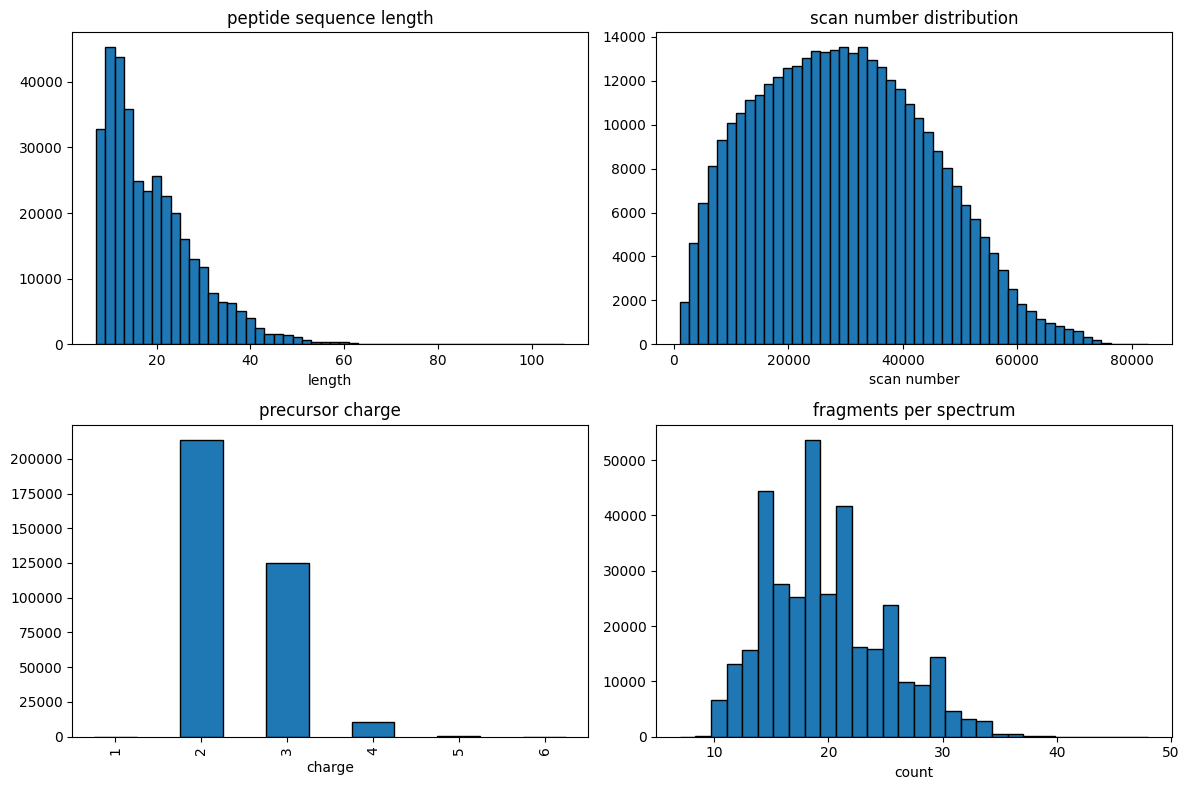

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# peptide sequence length
axes[0, 0].hist(df["peptide_sequence"].str.len(), bins=50, edgecolor="black")
axes[0, 0].set_title("peptide sequence length")
axes[0, 0].set_xlabel("length")

# scan number
axes[0, 1].hist(df["scan_number"], bins=50, edgecolor="black")
axes[0, 1].set_title("scan number distribution")
axes[0, 1].set_xlabel("scan number")

# precursor charge
meta["precursor_charge"].value_counts().sort_index().plot.bar(ax=axes[1, 0], edgecolor="black")
axes[1, 0].set_title("precursor charge")
axes[1, 0].set_xlabel("charge")

# fragments per spectrum
axes[1, 1].hist(df["intensities_raw"].apply(len), bins=30, edgecolor="black")
axes[1, 1].set_title("fragments per spectrum")
axes[1, 1].set_xlabel("count")

plt.tight_layout()
plt.show()

In [ ]:
meta["precursor_charge"].value_counts()

precursor_charge
2    213729
3    125161
4     10943
5       217
1        57
6         6
Name: count, dtype: int64

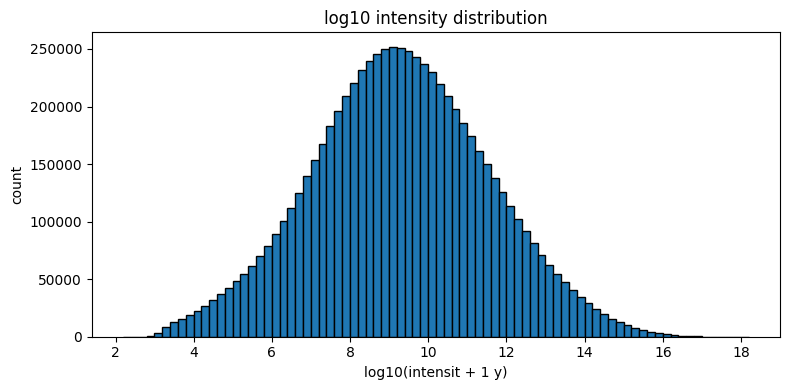

In [ ]:
# log-scaled intensity histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log(all_intensities + 1), bins=80, edgecolor="black") # +1 to not have log(0)
ax.set_title("log10 intensity distribution")
ax.set_xlabel("log10(intensit + 1 y)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## visualizations for presentation

/tmp/ipykernel_20613/1208302647.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="precursor_charge", data=df, palette="viridis", edgecolor="black")


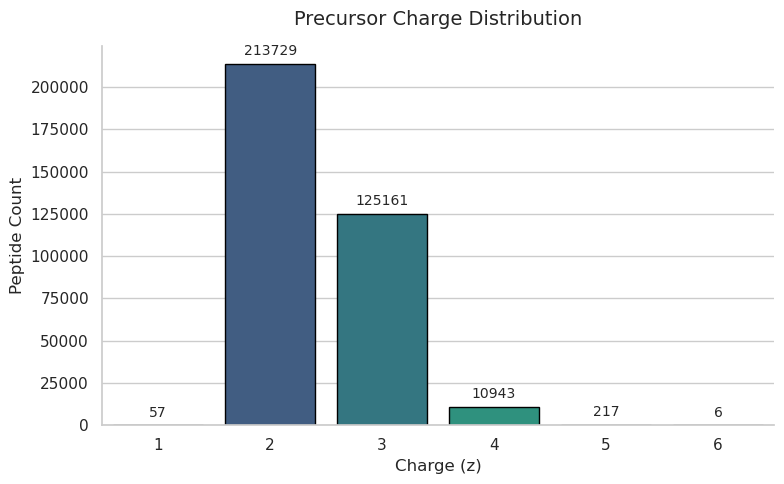

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_charge_distrib(df):

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8,5))

    ax = sns.countplot(x="precursor_charge", data=df, palette="viridis", edgecolor="black")

    plt.title('Precursor Charge Distribution', fontsize=14, pad=15)
    plt.xlabel('Charge (z)', fontsize=12)
    plt.ylabel('Peptide Count', fontsize=12)


    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', fontsize=10, xytext=(0,9), textcoords='offset points')
    sns.despine()
    plt.tight_layout()
    plt.show()


plot_charge_distrib(meta)


In [ ]:
(meta["precursor_charge"].value_counts() / len(meta) * 100).sort_index()

precursor_charge
1     0.016280
2    61.045720
3    35.748744
4     3.125562
5     0.061980
6     0.001714
Name: count, dtype: float64

## intensity heatmap

/tmp/ipykernel_20613/666627799.py:28: FutureWarning: The provided callable <function mean at 0x76008f3de7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = plot_df.pivot_table(index='type', columns='pos', values='intensity', aggfunc=np.mean)


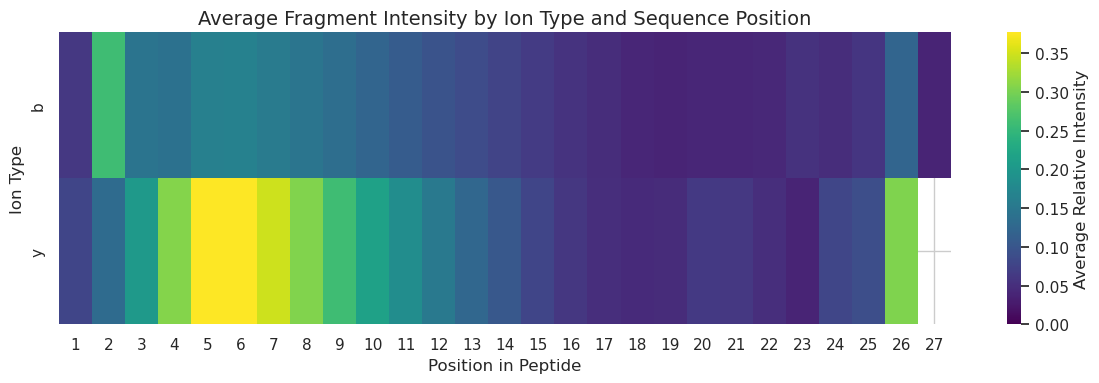

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_fragment_intensity_heatmap(df):
    
    sample_df = df.copy()

    data_list = []
    for _, row in sample_df.iterrows():
        ions = row["matched_ions"]
        its = np.array(row["intensities_raw"])
        
        if len(its) > 0 and its.max() > 0:
            its = its / its.max()
        
        for ion, intensity in zip(ions, its):
            if ion.startswith(('b', 'y')):
                data_list.append({
                    'type': ion[0],
                    'pos' : int(ion[1:]),
                    'intensity': intensity
                })

    plot_df = pd.DataFrame(data_list)

    pivot_table = plot_df.pivot_table(index='type', columns='pos', values='intensity', aggfunc=np.mean)
    
    vmax = pivot_table.quantile(0.95).max()

    plt.figure(figsize=(12,4))
    sns.heatmap(pivot_table, cmap='viridis', annot=False, vmin=0, vmax=vmax, cbar_kws={'label': 'Average Relative Intensity'})

    plt.title('Average Fragment Intensity by Ion Type and Sequence Position', fontsize=14)
    plt.xlabel('Position in Peptide', fontsize=12)
    plt.ylabel('Ion Type', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_fragment_intensity_heatmap(df)

## cleavage bias

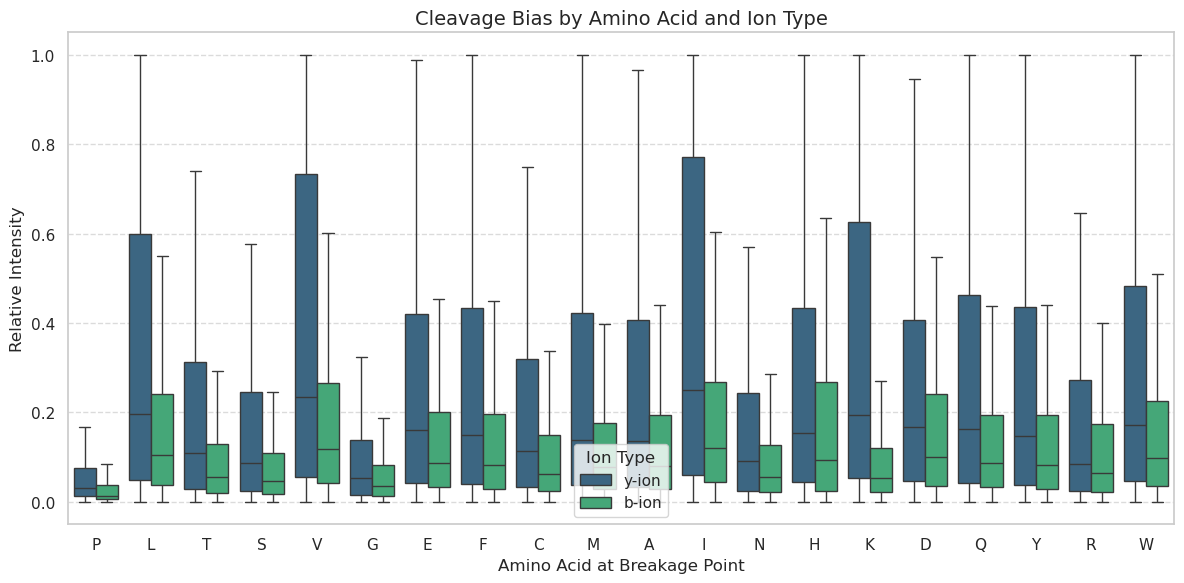

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot
import numpy as np
import re

def plot_cleavage_bias(df):
    data_list = []
    mod_pattern = re.compile(r"\[.*?]")

    for _, row in df.iterrows():
        clean_seq = mod_pattern.sub("", row["peptide_sequence"])
        ions = row["matched_ions"]
        its = np.array(row["intensities_raw"])

        if len(its) > 0 and its.max() > 0:
            its = its / its.max()

        for ion, intensity in zip(ions, its):
            if ion.startswith(('b', 'y')):
                try:
                    ion_type = ion[0]
                    pos = int(ion[1:])

                    if ion_type == 'b':
                        if pos < len(clean_seq):
                            aa = clean_seq[pos-1]
                            data_list.append({'AA': aa, 'Intensity': intensity, 'Type': 'b-ion'})
                    elif ion_type == 'y':
                        if pos < len(clean_seq):
                            aa = clean_seq[len(clean_seq) - pos - 1]
                            data_list.append({'AA': aa, 'Intensity': intensity, 'Type': 'y-ion'})
                except (IndexError, ValueError):
                    continue
        
    bias_df = pd.DataFrame(data_list)
    plt.figure(figsize=(12,6))
    sns.boxplot(x='AA', y='Intensity', hue='Type', data=bias_df, palette='viridis', fliersize=0)
    plt.title('Cleavage Bias by Amino Acid and Ion Type', fontsize=14)
    plt.xlabel('Amino Acid at Breakage Point', fontsize=12)
    plt.ylabel('Relative Intensity', fontsize=12)
    plt.legend(title='Ion Type')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_cleavage_bias(df)


## cleavage context heatmap (as seen in nature article)

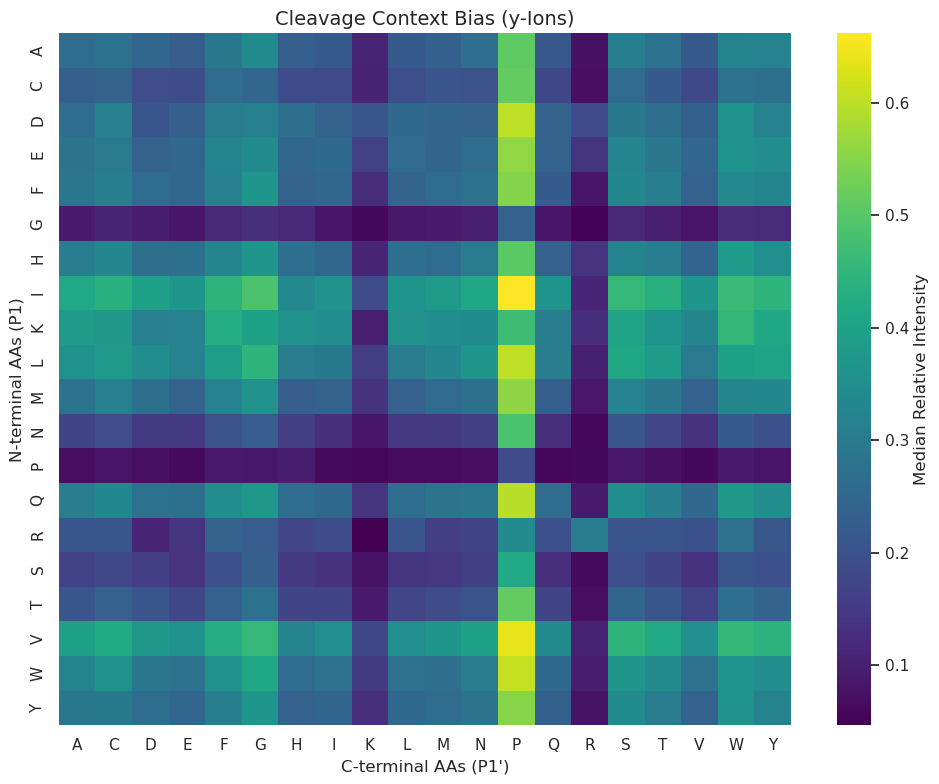

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_cleavage_context_heatmap_fast(df):
    aas = sorted(list("ACDEFGHIKLMNPQRSTVWY"))
    data_points = []
    mod_pattern = re.compile(r"\[.*?\]")

    sequences = [mod_pattern.sub("", seq) for seq in df["peptide_sequence"]]
    ions_list = df["matched_ions"].tolist()
    intensities_list = df["intensities_raw"].tolist()

    for seq, ions, its in zip(sequences, ions_list, intensities_list):
        if len(seq) < 2 or len(its) == 0: continue
        
        its = np.array(its)
        if its.max() > 0:
            its = its / its.max()
        else:
            continue
            
        for ion, intensity in zip(ions, its):
            if ion.startswith('y'):
                try:
                    pos = int(ion[1:])
                    idx = len(seq)  - pos - 1
                    
                    if 0 <= idx < len(seq) - 1:
                        aa_n = seq[idx]
                        aa_c = seq[idx+1]
                        if aa_n in aas and aa_c in aas:
                            data_points.append((aa_n, aa_c, intensity))
                except:
                    continue

    fast_df = pd.DataFrame(data_points, columns=['aa_n', 'aa_c', 'intensity'])
    matrix = fast_df.groupby(['aa_n', 'aa_c'])['intensity'].mean().unstack(fill_value=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, cmap='viridis', annot=False, cbar_kws={'label': 'Median Relative Intensity'})
    plt.title('Cleavage Context Bias (y-Ions)', fontsize=14)
    plt.xlabel('C-terminal AAs (P1\')',  fontsize=12)
    plt.ylabel('N-terminal AAs (P1)', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_cleavage_context_heatmap_fast(df) 

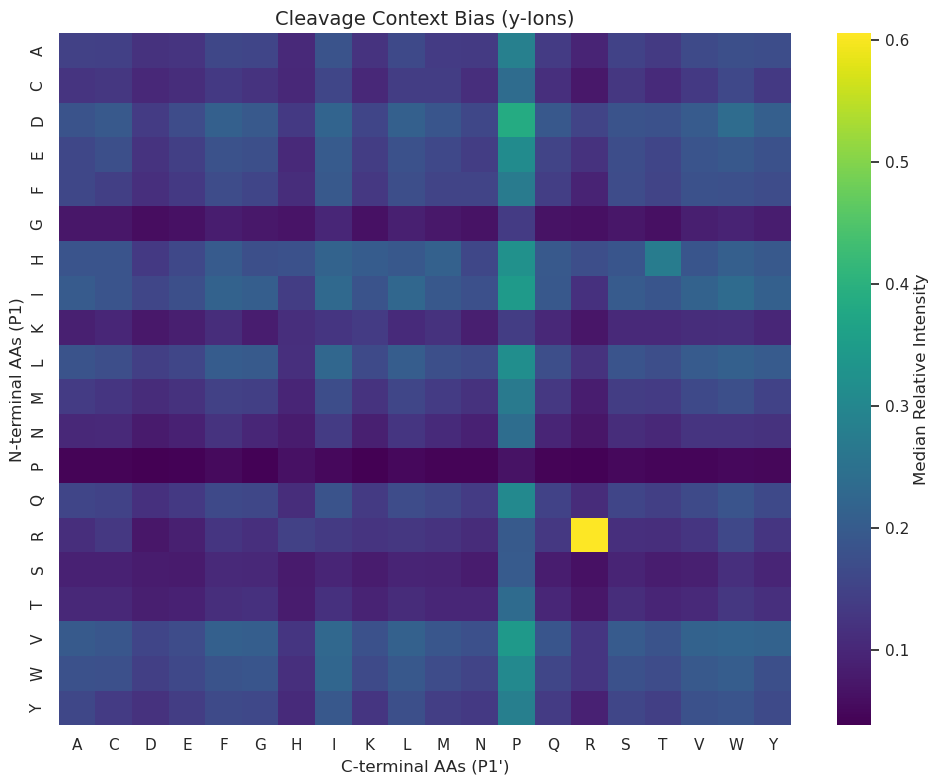

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_b_ion_context_heatmap_fast(df):
    aas = sorted(list("ACDEFGHIKLMNPQRSTVWY"))
    data_points = []
    mod_pattern = re.compile(r"\[.*?\]")

    sequences = [mod_pattern.sub("", seq) for seq in df["peptide_sequence"]]
    ions_list = df["matched_ions"].tolist()
    intensities_list = df["intensities_raw"].tolist()

    for seq, ions, its in zip(sequences, ions_list, intensities_list):
        if len(seq) < 2 or len(its) == 0: continue
        
        its = np.array(its)
        if its.max() > 0:
            its = its / its.max()
        else:
            continue
            
        for ion, intensity in zip(ions, its):
            if ion.startswith('b'):
                try:
                    pos = int(ion[1:])
                    idx = pos - 1
                    
                    if 0 <= idx < len(seq) - 1:
                        aa_n = seq[idx]
                        aa_c = seq[idx+1]
                        if aa_n in aas and aa_c in aas:
                            data_points.append((aa_n, aa_c, intensity))
                except:
                    continue

    fast_df = pd.DataFrame(data_points, columns=['aa_n', 'aa_c', 'intensity'])
    matrix = fast_df.groupby(['aa_n', 'aa_c'])['intensity'].mean().unstack(fill_value=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, cmap='viridis', annot=False, cbar_kws={'label': 'Median Relative Intensity'})
    plt.title('Cleavage Context Bias (y-Ions)', fontsize=14)
    plt.xlabel('C-terminal AAs (P1\')',  fontsize=12)
    plt.ylabel('N-terminal AAs (P1)', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_b_ion_context_heatmap_fast(df)